<a href="https://colab.research.google.com/github/Areej973/Stc-tasks/blob/main/stc_TV_T2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STC Jawwy

In [1]:
"""
Here we install libraries that are not installed by default
Example:  pyslsb
Feel free to add any library you are planning to use.
"""
!pip install pyxlsb

In [2]:
# Import the required libraries
"""
Please feel free to import any required libraries as per your needs
"""
import pandas as pd     # provides high-performance, easy to use structures and data analysis tools
import pyxlsb           # Excel extention to read xlsb files (the input file)
import numpy as np      # provides fast mathematical computation on arrays and matrices

# Jawwy dataset
The dataset includes total watching hours for customers per day.

You are required to work on predecting the forecast for the watching hours.

In [5]:
dataframe = pd.read_excel("/content/stc TV Data Set_T2.xlsx",index_col=0)
# Please make a copy of dataset if you are going to work directly and make changes on the dataset
# you can use   df=dataframe.copy()

In [6]:
# check the data shape
dataframe.shape

(86, 2)

In [7]:
# display the first 5 rows
dataframe.head()

,date_,Total_watch_time_in_houres
0,2018-01-01,1123.551944
1,2018-01-02,1000.129722
2,2018-01-03,881.924444
3,2018-01-04,782.669444
4,2018-01-05,1051.939444


In [8]:
# display the dataset after applying data types
dataframe.head()

,date_,Total_watch_time_in_houres
0,2018-01-01,1123.551944
1,2018-01-02,1000.129722
2,2018-01-03,881.924444
3,2018-01-04,782.669444
4,2018-01-05,1051.939444


In [9]:
# describe the numeric values in the dataset
dataframe.describe()

,date_,Total_watch_time_in_houres
count,86,86.000000
mean,2018-02-28 17:01:23.720930304,780.817926
min,2018-01-01 00:00:00,562.124722
25%,2018-01-30 06:00:00,707.709653
50%,2018-02-28 12:00:00,763.181389
75%,2018-03-29 18:00:00,840.985278
max,2018-04-30 00:00:00,1123.551944
std,NaN,122.992002


In [10]:
# check if any column has null value in the dataset
dataframe.isnull().any()

,0
date_,False
Total_watch_time_in_houres,False


In [11]:
# we import Visualization libraries
# you can ignore and use any other graphing libraries
import matplotlib.pyplot as plt # a comprehensive library for creating static, animated, and interactive visualizations
import plotly #a graphing library makes interactive, publication-quality graphs. Examples of how to make line plots, scatter plots, area charts, bar charts, error bars, box plots, histograms, heatmaps, subplots, multiple-axes, polar charts, and bubble charts.
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [12]:
# Setting the date as index
dataframe.set_index('date_', inplace=True)

In [13]:
# Display the dataframe after setting the date as index
dataframe.head()

,Total_watch_time_in_houres
date_,
2018-01-01,1123.551944
2018-01-02,1000.129722
2018-01-03,881.924444
2018-01-04,782.669444
2018-01-05,1051.939444


In [14]:
# show the dataframe
fig = px.line(dataframe,  y="Total_watch_time_in_houres")
fig.show()

In [ ]:
"""
TODO using the previous dataset (df) build a prediction model to predict the expected watch time for the next two months
Hint: you can build a forecast model to predict the results
"""

'\nTODO using the previous dataset (df) build a prediction model to predict the expected watch time for the next two months\nHint: you can build a forecast model to predict the results\n'

In [15]:
# Make a copy of the dataset for forecasting
df = dataframe.copy()


In [16]:
df = df.sort_index()
df.head()


,Total_watch_time_in_houres
date_,
2018-01-01,1123.551944
2018-01-02,1000.129722
2018-01-03,881.924444
2018-01-04,782.669444
2018-01-05,1051.939444


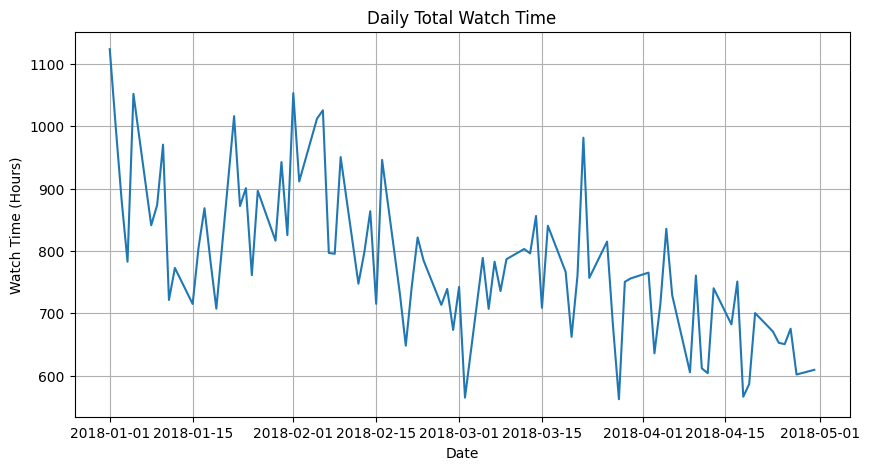

In [17]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['Total_watch_time_in_houres'])
plt.title('Daily Total Watch Time')
plt.xlabel('Date')
plt.ylabel('Watch Time (Hours)')
plt.grid(True)
plt.show()


In [18]:
from statsmodels.tsa.arima.model import ARIMA

# Build ARIMA model
model = ARIMA(df['Total_watch_time_in_houres'], order=(1,1,1))
model_fit = model.fit()

model_fit.summary()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency B will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency B will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency B will be used.



<class 'statsmodels.iolib.summary.Summary'>
"""
                                   SARIMAX Results                                    
======================================================================================
Dep. Variable:     Total_watch_time_in_houres   No. Observations:                   86
Model:                         ARIMA(1, 1, 1)   Log Likelihood                -510.460
Date:                        Fri, 30 Jan 2026   AIC                           1026.920
Time:                                03:56:57   BIC                           1034.248
Sample:                            01-01-2018   HQIC                          1029.867
                                 - 04-30-2018                                         
Covariance Type:                          opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1052      0.150     -0.702      0.483      -0.399       0.189
ma.L1         -0.7169      0.109     -6.559      0.000      -0.931      -0.503
sigma2      9574.0650   1629.821      5.874      0.000    6379.675    1.28e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 0.40
Prob(Q):                              0.89   Prob(JB):                         0.82
Heteroskedasticity (H):               0.61   Skew:                             0.09
Prob(H) (two-sided):                  0.20   Kurtosis:                         2.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
forecast_steps = 60
forecast = model_fit.forecast(steps=forecast_steps)

forecast_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=forecast_steps
)

forecast_df = pd.DataFrame({
    'Predicted_watch_time_in_houres': forecast
}, index=forecast_dates)

forecast_df.head()


,Predicted_watch_time_in_houres
2018-05-01,638.671956
2018-05-02,635.579166
2018-05-03,635.904626
2018-05-04,635.870377
2018-05-05,NaN


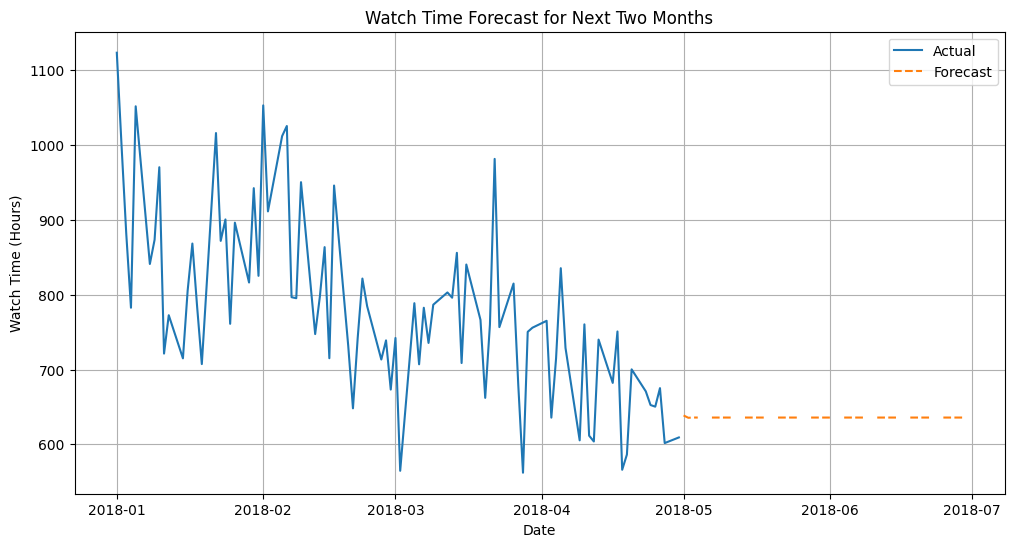

In [20]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Total_watch_time_in_houres'], label='Actual')
plt.plot(forecast_df.index, forecast_df['Predicted_watch_time_in_houres'],
         label='Forecast', linestyle='--')

plt.title('Watch Time Forecast for Next Two Months')
plt.xlabel('Date')
plt.ylabel('Watch Time (Hours)')
plt.legend()
plt.grid(True)
plt.show()
